# Step 5


In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path
import matplotlib.cm as cm
from matplotlib.patches import Polygon, Patch, Rectangle
from scipy.spatial import ConvexHull

In [ ]:
#names of the dot files that contain the data:
data_name_1 = "../Datasets/JazzNetwork.dot"
data_name_2 = "../Datasets/LesMiserables.dot"
data_name_3 = "../Datasets/devonshiredebate_withclusters.dot"
data_name_4 = "../Datasets/g.20.27.dot"
data_name_5 = "../Datasets/g.42.88.dot"
data_name_6 = "../Datasets/GD97.dot"
data_name_7 = "../Datasets/LeagueNetwork.dot" 
data_name_8 = "../Datasets/mesh graph.dot"
data_name_9 = "../Datasets/noname.dot" 
data_name_10 = "../Datasets/polblogs.dot"
data_name_11 = "../Datasets/robot graph.dot"
data_name_12 = "../Datasets/rome.dot"
data_name_13 = "../Datasets/snail graph.dot"

## Bounding boxes:

In [3]:
def process_dot_file_for_subgraphs(file_path, subgraph_names):
    """
    Process a DOT file and extract specified subgraphs.
    
    Parameters:
    -----------
    file_path : str
        Path to the DOT file
    subgraph_names : list
        List of subgraph names to extract
        
    Returns:
    --------
    dict
        Dictionary with:
        - 'subgraphs': Dict mapping subgraph name to list of nodes with attributes
        - 'edges': List of edge tuples (source, target, attributes)
    """
    # Parse the DOT file
    dot_graphs = pydot.graph_from_dot_file(file_path)
    dot_graph = dot_graphs[0]  # Assume there's only one main graph
    
    # Process subgraphs
    subgraphs = {}
    subgraph_objects = {}
    
    # Extract all subgraphs
    for subgraph in dot_graph.get_subgraphs():
        name = subgraph.get_name().strip('"')
        if name in subgraph_names:
            subgraphs[name] = []
            subgraph_objects[name] = subgraph
            
            # Process nodes in this subgraph
            for node in subgraph.get_nodes():
                node_id = node.get_name().strip('"')
                attrs = {k: v.strip('"') for k, v in node.get_attributes().items()}
                # Add node with its attributes
                subgraphs[name].append((node_id, attrs))
    
    # Extract node IDs for edge filtering
    all_nodes = set()
    for name in subgraphs:
        for node_id, _ in subgraphs[name]:
            all_nodes.add(node_id)
    
    # Extract edges where both endpoints are in the included subgraphs
    edges = []
    for edge in dot_graph.get_edges():
        source = edge.get_source().strip('"')
        target = edge.get_destination().strip('"')
        
        if source in all_nodes and target in all_nodes:
            attrs = {k: v.strip('"') for k, v in edge.get_attributes().items()}
            edges.append((source, target, attrs))
    
    return {
        'subgraphs': subgraphs,
        'edges': edges
    }

def draw_colorful_FDG_FR_inertia_subgraphs(
    subgraphs_data, 
    output_name=None, 
    iterations=100, 
    C=1.0,
    save_frames=False, 
    output_dir="Output_subgraphs", 
    subgraph_names=None,
    convergence_threshold=0.001, 
    display_node_id=False,
    separation_factor=1.5,  # Controls overall scale
    subgraph_spacing=0.5    # Controls space BETWEEN subgraphs
):
    """
    Draw a force-directed graph layout with subgraphs placed in different regions,
    with each subgraph running its own force-directed layout until convergence.
    
    Parameters:
    -----------
    subgraphs_data : dict
        Dictionary with 'subgraphs' and 'edges' as returned by process_dot_file_for_subgraphs
    output_name : str, optional
        Path to save the final output image
    iterations : int, optional
        Maximum number of iterations for the algorithm
    C : float, optional
        Force constant scaling factor
    save_frames : bool, optional
        Whether to save intermediate frames
    output_dir : str, optional
        Base directory to save frames
    subgraph_names : list, optional
        List of subgraph names (used for creating subfolder)
    convergence_threshold : float, optional
        Threshold for considering the layout converged
    display_node_id : bool, optional
        Whether to display node IDs
    separation_factor : float, optional
        Controls the overall scale of the visualization
    subgraph_spacing : float, optional
        Controls the space between subgraphs (0.0=touching, 1.0=wide spacing)
    """
    # Extract subgraphs and edges
    subgraphs = subgraphs_data['subgraphs']
    edges_data = subgraphs_data['edges']
    
    # Create a subfolder name from subgraph names
    if subgraph_names:
        subfolder_name = "_".join([re.sub(r'[^\w\-_]', '_', name) for name in subgraph_names])
        if len(subfolder_name) > 50:
            subfolder_name = subfolder_name[:47] + "..."
        full_output_dir = os.path.join(output_dir, subfolder_name)
    else:
        full_output_dir = output_dir
    
    # Create output directory if it doesn't exist
    if save_frames and not os.path.exists(full_output_dir):
        os.makedirs(full_output_dir)
    
    # Create a NetworkX graph
    G = nx.DiGraph()
    
    # Track node to subgraph mapping
    node_to_subgraph = {}
    
    # Add nodes with attributes
    for subgraph_name, nodes_data in subgraphs.items():
        for node_id, attrs in nodes_data:
            G.add_node(node_id, **attrs, subgraph=subgraph_name)
            node_to_subgraph[node_id] = subgraph_name
    
    # Add edges with attributes
    for source, target, attrs in edges_data:
        G.add_edge(source, target, **attrs)
    
    # Extract nodes and edges
    nodes = list(G.nodes())
    edges = list(G.edges())
    
    # Total number of nodes
    n = len(nodes)
    
    # Number of subgraphs
    num_subgraphs = len(subgraphs)
    
    # Calculate how many nodes are in each subgraph
    subgraph_node_counts = {name: len(nodes_data) for name, nodes_data in subgraphs.items()}
    
    # Get node degrees and calculate masses
    node_degrees = {node: len(list(G.neighbors(node))) for node in nodes}
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}
    
    # Create colormap for subgraphs
    color_map = {}
    for i, subgraph_name in enumerate(subgraphs.keys()):
        color_map[subgraph_name] = plt.cm.tab10(i % 10)
    
    # Calculate base size for subgraph regions based on node counts
    total_nodes = sum(subgraph_node_counts.values())
    base_region_size = math.sqrt(n) / 4 * separation_factor
    
    # Determine canvas divisions based on subgraph count
    if num_subgraphs <= 1:
        grid_rows = grid_cols = 1
    elif num_subgraphs <= 2:
        grid_rows = 1
        grid_cols = 2
    elif num_subgraphs <= 4:
        grid_rows = grid_cols = 2
    else:
        grid_rows = grid_cols = math.ceil(math.sqrt(num_subgraphs))
    
    # Calculate subgraph region sizes proportionally to their node count
    # Ensure every subgraph gets at least a minimum size
    min_region_size = base_region_size * 0.5
    subgraph_sizes = {}
    for name, count in subgraph_node_counts.items():
        size = max(min_region_size, base_region_size * math.sqrt(count / max(1, total_nodes/num_subgraphs)))
        subgraph_sizes[name] = size
    
    # Calculate total width and height needed with spacing
    max_width_per_col = [0] * grid_cols
    max_height_per_row = [0] * grid_rows
    
    # Assign positions in grid and track max dimensions
    idx = 0
    subgraph_positions = {}
    for name, size in subgraph_sizes.items():
        row = idx // grid_cols
        col = idx % grid_cols
        subgraph_positions[name] = {'row': row, 'col': col, 'size': size}
        
        max_width_per_col[col] = max(max_width_per_col[col], size)
        max_height_per_row[row] = max(max_height_per_row[row], size)
        idx += 1
    
    # Calculate spacing between regions
    spacing_x = base_region_size * subgraph_spacing
    spacing_y = base_region_size * subgraph_spacing
    
    # Calculate total canvas dimensions
    total_width = sum(max_width_per_col) + spacing_x * (grid_cols - 1)
    total_height = sum(max_height_per_row) + spacing_y * (grid_rows - 1)
    
    # Now calculate actual positions with spacing
    x_offsets = [0] * grid_cols
    y_offsets = [0] * grid_rows
    running_x = 0
    for i in range(grid_cols):
        x_offsets[i] = running_x
        running_x += max_width_per_col[i] + spacing_x
    
    running_y = 0
    for i in range(grid_rows):
        y_offsets[i] = running_y
        running_y += max_height_per_row[i] + spacing_y
    
    # Assign final regions to each subgraph
    subgraph_regions = {}
    for name, pos_data in subgraph_positions.items():
        row = pos_data['row']
        col = pos_data['col']
        size = pos_data['size']
        
        # Calculate center position
        center_x = x_offsets[col] + max_width_per_col[col] / 2
        center_y = y_offsets[row] + max_height_per_row[row] / 2
        
        # Define region boundaries
        x_min = center_x - size/2
        y_min = center_y - size/2
        x_max = center_x + size/2
        y_max = center_y + size/2
        
        subgraph_regions[name] = {
            'x_min': x_min, 'x_max': x_max,
            'y_min': y_min, 'y_max': y_max,
            'center': (center_x, center_y),
            'width': size,
            'height': size,
            'radius': size / 2
        }
    
    # SCALING: Adjust figure size 
    fig_width = max(10, min(24, 8 + math.sqrt(n)))
    fig_height = max(8, min(20, 6 + math.sqrt(n)))
    
    # SCALING: Calculate node size and font size based on total nodes
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Set view limits for the entire canvas with padding
    view_padding = base_region_size * 0.1
    view_x_min = -view_padding
    view_y_min = -view_padding
    view_x_max = total_width + view_padding
    view_y_max = total_height + view_padding
    
    # Optimal force constant per subgraph
    subgraph_l = {}
    for name, nodes_data in subgraphs.items():
        subgraph_n = len(nodes_data)
        region = subgraph_regions[name]
        region_area = region['width'] * region['height']
        subgraph_l[name] = C * math.sqrt(region_area / max(1, subgraph_n))
    
    # Group edges by subgraph
    subgraph_edges = {name: [] for name in subgraphs.keys()}
    cross_subgraph_edges = []
    
    for u, v in edges:
        u_subgraph = node_to_subgraph[u]
        v_subgraph = node_to_subgraph[v]
        
        if u_subgraph == v_subgraph:
            subgraph_edges[u_subgraph].append((u, v))
        else:
            cross_subgraph_edges.append((u, v))
    
    # Group nodes by subgraph
    subgraph_nodes = {name: [node_id for node_id, _ in data] for name, data in subgraphs.items()}
    
    # Initialize node positions within their assigned regions
    pos = {}
    for node in nodes:
        subgraph_name = node_to_subgraph[node]
        region = subgraph_regions[subgraph_name]
        
        # Random position within the region
        x = random.uniform(region['x_min'], region['x_max'])
        y = random.uniform(region['y_min'], region['y_max'])
        pos[node] = np.array([x, y])
    
    # Prepare the figure and set fixed bounds
    plt.figure(figsize=(fig_width, fig_height))
    
    # Track convergence for each subgraph
    subgraph_converged = {name: False for name in subgraphs.keys()}
    max_movement_by_subgraph = {name: float('inf') for name in subgraphs.keys()}
    
    # Frame counter
    frame_count = 0
    
    # Initial plot to set the view bounds
    plt.clf()
    plt.xlim(view_x_min, view_x_max)
    plt.ylim(view_y_min, view_y_max)
    
    # Draw region boundaries
    for subgraph_name, region in subgraph_regions.items():
        color = color_map[subgraph_name]
        rect = Rectangle(
            (region['x_min'], region['y_min']),
            region['width'], region['height'],
            fill=True, alpha=0.1, linewidth=2,
            edgecolor=color, facecolor=color, zorder=0
        )
        plt.gca().add_patch(rect)
    
    # Draw initial positions
    for node in nodes:
        subgraph_name = node_to_subgraph[node]
        node_color = color_map[subgraph_name]
        plt.scatter(pos[node][0], pos[node][1], s=node_size, color=node_color, edgecolor='black', zorder=2)
    
    plt.title("Initial Layout")
    plt.axis('off')
    plt.tight_layout()
    
    # Save initial frame
    if save_frames:
        frame_path = os.path.join(full_output_dir, f"subgraph_layout_iter_0000.png")
        plt.savefig(frame_path, dpi=150)
    
    plt.pause(0.1)  # Pause to allow the GUI to update
    
    # Main layout loop - run until all subgraphs converge or max iterations reached
    iteration = 0
    previous_converged_status = {name: False for name in subgraphs.keys()}
    newly_converged = False

    while iteration < iterations and not all(subgraph_converged.values()):
        iteration += 1
        newly_converged = False  # Reset at the beginning of each iteration
        
        # Process each subgraph independently if not yet converged
        for subgraph_name in subgraphs.keys():
            if subgraph_converged[subgraph_name]:
                continue  # Skip subgraphs that have already converged
            
            # Initial temperature per subgraph
            t = 0.1 * (0.95 ** iteration)  # Cooling schedule
            
            # Get nodes and edges for this subgraph
            sg_nodes = subgraph_nodes[subgraph_name]
            sg_edges = subgraph_edges[subgraph_name]
            region = subgraph_regions[subgraph_name]
            l = subgraph_l[subgraph_name]
            
            # Skip if no nodes
            if not sg_nodes:
                subgraph_converged[subgraph_name] = True
                continue
            
            # Save previous positions for this subgraph
            prev_pos = {node: np.copy(pos[node]) for node in sg_nodes}
            
            # Initialize force vectors for this subgraph
            f_total = {node: np.array([0.0, 0.0]) for node in sg_nodes}
            
            # PHASE 1: Calculate REPULSIVE forces within subgraph
            for u in sg_nodes:
                for v in sg_nodes:
                    if u != v:
                        # Vector from u to v
                        delta = pos[v] - pos[u]
                        
                        # Euclidean distance (prevent division by zero)
                        distance = max(0.01, np.linalg.norm(delta))
                        
                        # Calculate repulsive force
                        repulsive_magnitude = (l * l) / distance
                        
                        # Direction
                        direction = delta / distance
                        
                        # Apply repulsive force
                        f_total[u] -= direction * repulsive_magnitude
            
            # PHASE 2: Calculate ATTRACTIVE forces within subgraph
            for u, v in sg_edges:
                # Vector from u to v
                delta = pos[v] - pos[u]
                
                # Euclidean distance
                distance = max(0.01, np.linalg.norm(delta))
                
                # Calculate attractive force
                attractive_magnitude = (distance * distance) / l
                
                # Direction
                direction = delta / distance
                
                # Apply attraction to both nodes
                f_total[u] += direction * attractive_magnitude / node_masses[u]
            
            # PHASE 3: Add containment forces to keep nodes within their region
            containment_strength = 10.0  # Strong containment force
            for node in sg_nodes:
                # Calculate distance to region boundaries
                x, y = pos[node]
                
                # Apply forces to keep node within the region
                if x < region['x_min']:
                    force = region['x_min'] - x
                    f_total[node][0] += containment_strength * force
                if x > region['x_max']:
                    force = region['x_max'] - x
                    f_total[node][0] += containment_strength * force
                    
                if y < region['y_min']:
                    force = region['y_min'] - y
                    f_total[node][1] += containment_strength * force
                if y > region['y_max']:
                    force = region['y_max'] - y
                    f_total[node][1] += containment_strength * force
                
                # Also add a light gravity towards center
                center_x, center_y = region['center']
                dx = center_x - x
                dy = center_y - y
                distance = max(0.01, math.sqrt(dx*dx + dy*dy))
                
                # Weak gravity toward center (stronger if near edges)
                edge_proximity = min(
                    abs(x - region['x_min']),
                    abs(x - region['x_max']),
                    abs(y - region['y_min']),
                    abs(y - region['y_max'])
                ) / min(region['width'], region['height'])
                
                gravity_strength = 0.03 * (1 + (1 - min(1, edge_proximity)) * 2)
                
                f_total[node][0] += gravity_strength * dx
                f_total[node][1] += gravity_strength * dy
            
            # PHASE 4: Update positions with Hard boundary enforcement for this subgraph
            for node in sg_nodes:
                pos[node][0] = max(region['x_min'], min(region['x_max'], pos[node][0]))
                pos[node][1] = max(region['y_min'], min(region['y_max'], pos[node][1]))
            
            # Calculate maximum movement for this subgraph
            movements = [np.linalg.norm(pos[node] - prev_pos[node]) for node in sg_nodes]
            max_movement = max(movements) if movements else 0
            max_movement_by_subgraph[subgraph_name] = max_movement
            
            # Check if this subgraph has converged
            if max_movement <= convergence_threshold:
                subgraph_converged[subgraph_name] = True
                print(f"Subgraph '{subgraph_name}' converged at iteration {iteration} with max movement {max_movement:.6f}")
            
            for subgraph_name in subgraphs.keys():
                if subgraph_converged[subgraph_name] and not previous_converged_status[subgraph_name]:
                    newly_converged = True
                    print(f"Subgraph '{subgraph_name}' newly converged at iteration {iteration}")
        
            # Update previous status for next iteration
            previous_converged_status = dict(subgraph_converged)
        
        
        # Draw the graph at intervals or when a subgraph converges
        def actual_drawing(subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id):
            plt.clf()

            # Set fixed axis limits to maintain consistent zoom
            plt.xlim(view_x_min, view_x_max)
            plt.ylim(view_y_min, view_y_max)

            # Draw region boundaries
            for subgraph_name, region in subgraph_regions.items():
                color = color_map[subgraph_name]
                rect = Rectangle(
                    (region['x_min'], region['y_min']),
                    region['width'], region['height'],
                    fill=True, alpha=0.1, linewidth=2,
                    edgecolor=color, facecolor=color, zorder=0
                )
                plt.gca().add_patch(rect)

            # Draw subgraph convex hulls
            for subgraph_name, sg_node_list in subgraph_nodes.items():
                if sg_node_list:
                    # Get positions of all nodes in this subgraph
                    x_coords = [pos[node][0] for node in sg_node_list]
                    y_coords = [pos[node][1] for node in sg_node_list]

                    if x_coords and y_coords and len(x_coords) > 2:
                        try:
                            # Calculate the convex hull
                            points = np.vstack((x_coords, y_coords)).T
                            hull = ConvexHull(points)
                            hull_points = points[hull.vertices]

                            # Draw hull
                            color = color_map[subgraph_name]
                            polygon = Polygon(hull_points, fill=True, alpha=0.2, 
                                             facecolor=color, edgecolor=color, 
                                             linewidth=2, zorder=0.5)
                            plt.gca().add_patch(polygon)
                        except:
                            pass  # Skip hull drawing if it fails
                        
            # Draw all edges
            for u, v in edges:
                # Get edge type for styling
                edge_type = G.edges[u, v].get('edge_type', 'default')
                color = 'gray'
                linestyle = '-'


                # Cross-subgraph edges are fainter
                alpha = 0.3 if node_to_subgraph[u] != node_to_subgraph[v] else 0.6

                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                        color=color, alpha=alpha, zorder=1, 
                        linewidth=edge_width, linestyle=linestyle)

            # Draw nodes
            for node in nodes:
                # Get node attributes
                node_type = G.nodes[node].get('type', '')
                subgraph_name = node_to_subgraph[node]
                marker = 'o'

                # Get color from subgraph
                node_color = color_map[subgraph_name]

                plt.scatter(pos[node][0], pos[node][1], 
                           s=node_size, color=node_color, 
                           edgecolor='black', zorder=2, marker=marker)

                # Display node labels if requested
                if display_node_id:
                    # Use node title as label if available, otherwise use node ID
                    label = G.nodes[node].get('title', node)
                    if len(label) > 20:
                        label = label[:17] + "..."
                    plt.text(pos[node][0], pos[node][1], label, 
                            ha='center', va='center', fontsize=font_size, 
                            fontname='sans-serif', zorder=3)

            # Add legends
            legend_patches = []
            for subgraph_name, color in color_map.items():
                # Add convergence status to the legend
                status = "✓" if subgraph_converged[subgraph_name] else f"({max_movement_by_subgraph[subgraph_name]:.4f})"
                legend_patches.append(Patch(color=color, label=f"{subgraph_name} {status}"))

            plt.legend(handles=legend_patches, loc='best', fontsize=font_size)


            plt.axis('off')
            plt.tight_layout()
    
            # Save the current frame if requested
            if save_frames:
                frame_path = os.path.join(full_output_dir, f"subgraph_layout_iter_{frame_count:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {frame_count} to {frame_path}")

            # Pause to allow interface update
            plt.pause(0.01)

        
        #if iteration % 10 == 0 or iteration == iterations or newly_converged:
        if iteration == iterations or newly_converged:
            frame_count += 1
            actual_drawing(subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id)
    
    
    # Show the final graph
    plt.show()
    # returning an array of elements needed for the actual drawing: subgraph_name, region, color_map, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id
    return_array = [subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id]
    return G, pos, return_array

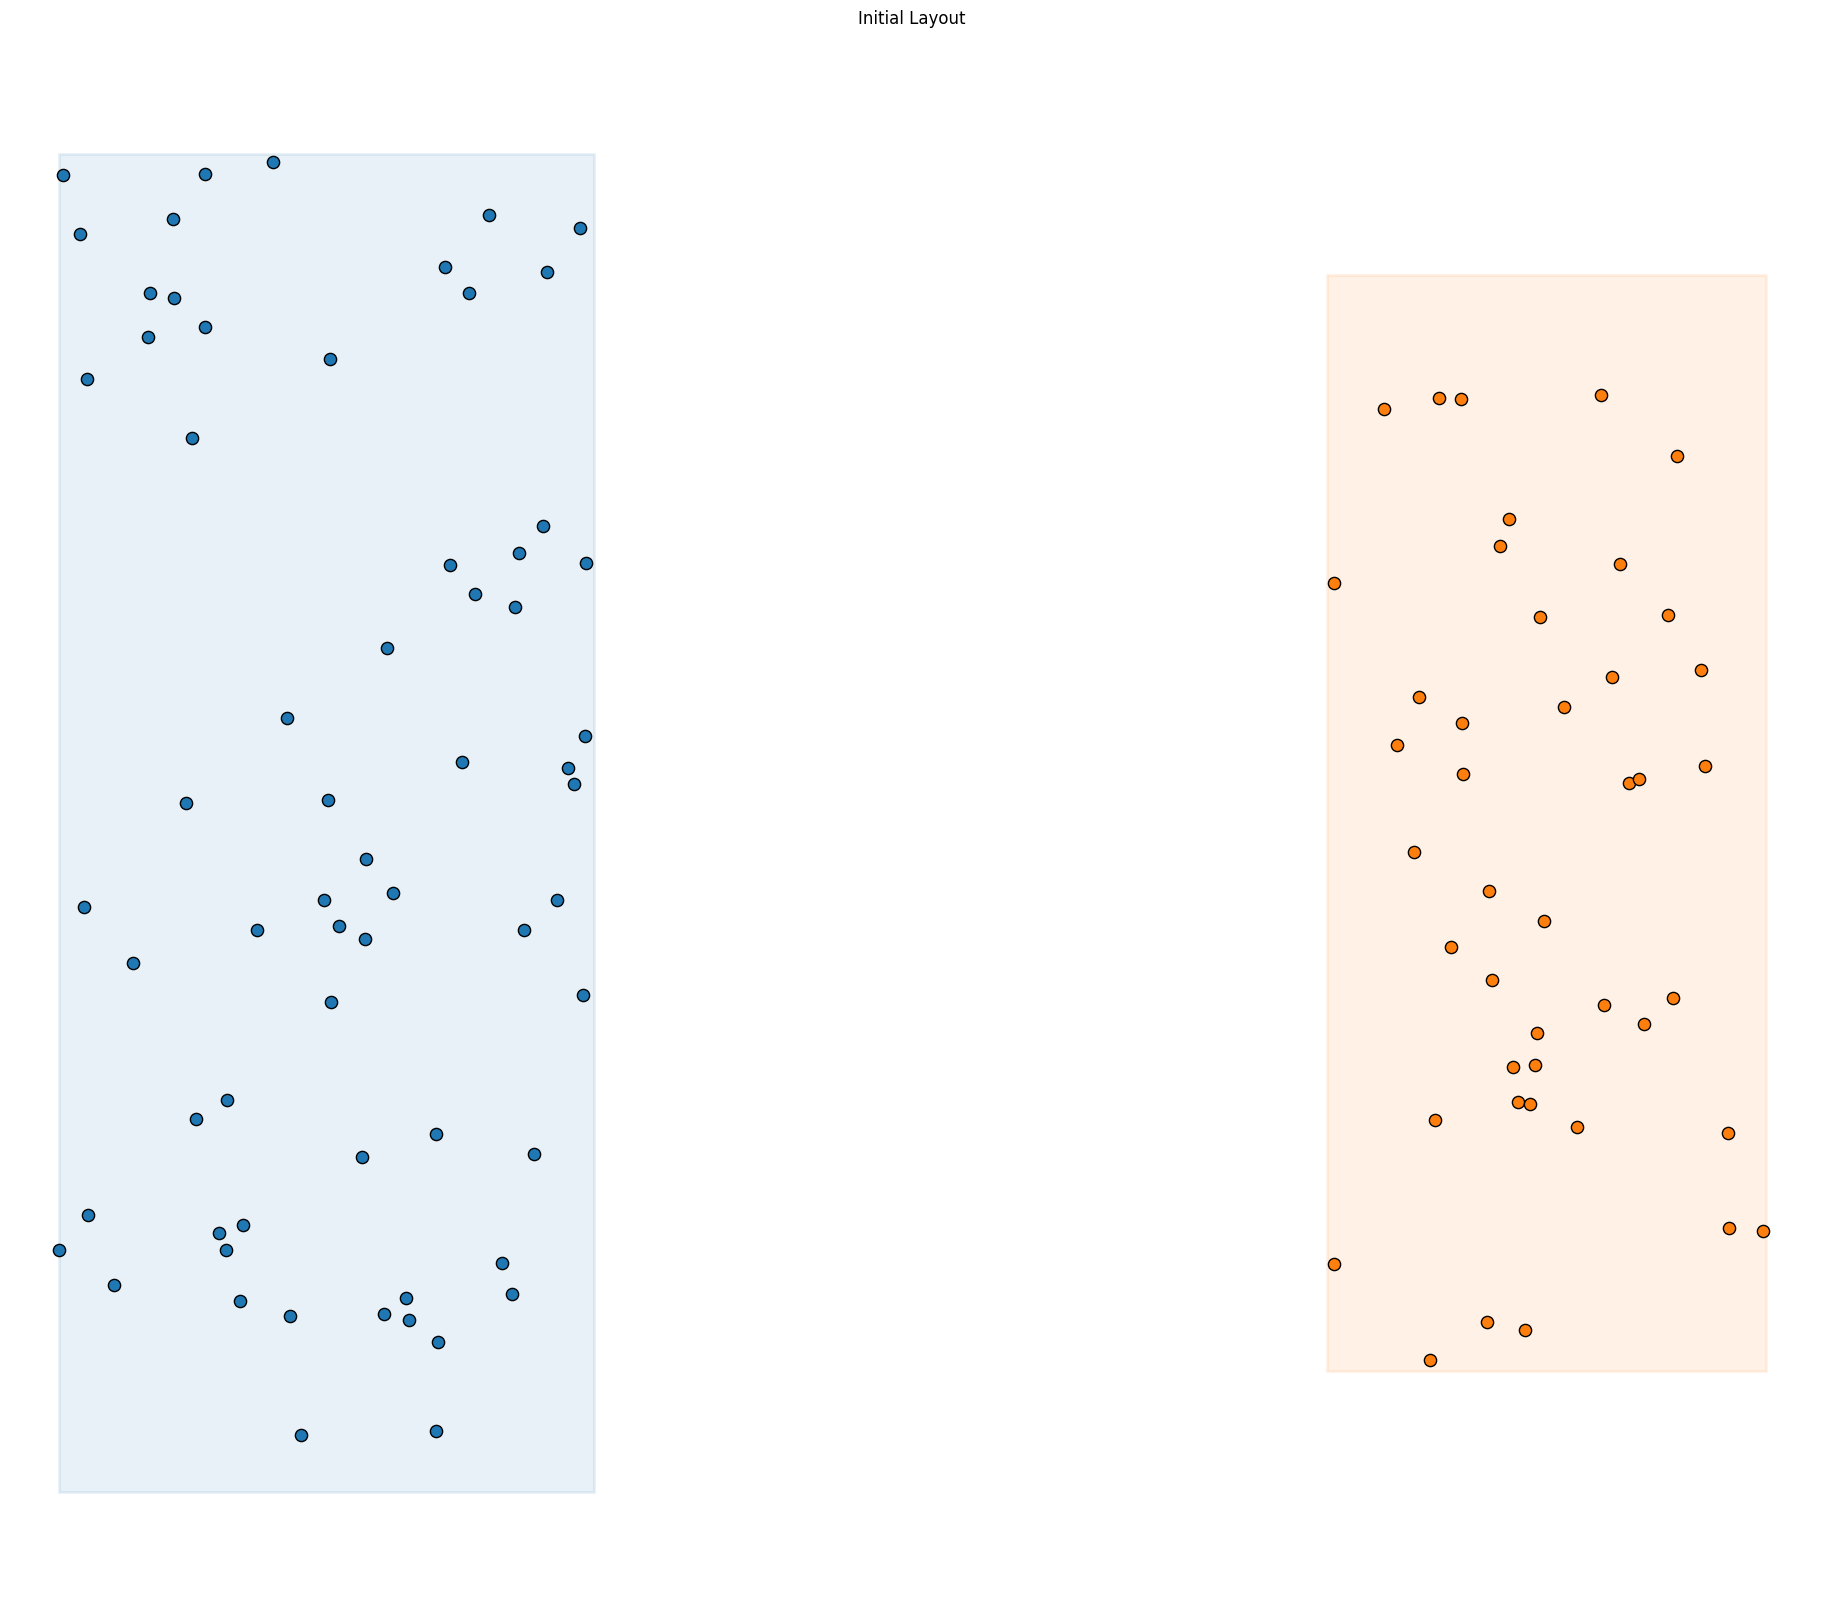

Subgraph 'Youngest Devonian Strata' converged at iteration 1 with max movement 0.000000
Subgraph 'Youngest Devonian Strata' newly converged at iteration 1
Subgraph 'Gap in the Sequence of Devonshi' converged at iteration 1 with max movement 0.000000
Subgraph 'Gap in the Sequence of Devonshi' newly converged at iteration 1


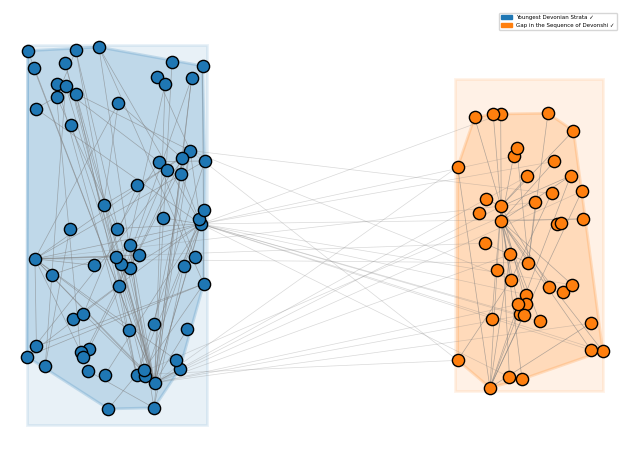

In [4]:
# Example usage
dot_file_path = data_name_3
subgraph_names = ["Youngest Devonian Strata", "Gap in the Sequence of Devonshi"]

# Process the DOT file and get subgraphs data
subgraphs_data = process_dot_file_for_subgraphs(dot_file_path, subgraph_names)

# Visualize the subgraphs and get the graph and positions
visualization_elements = []
G, pos, visualization_elements = draw_colorful_FDG_FR_inertia_subgraphs( subgraphs_data, iterations=300, display_node_id=False, save_frames=False, separation_factor=2.0,
    subgraph_spacing=1.5, convergence_threshold=0.0005)

Drawing the frame from the last iteration: 

## Edge Boundling:

In [5]:
# Get nodes in each cluster
cluster1_nodes = [node for node, attrs in subgraphs_data['subgraphs'][subgraph_names[0]]]
cluster2_nodes = [node for node, attrs in subgraphs_data['subgraphs'][subgraph_names[1]]]
inter_cluster_edges = [(u, v) for u, v in G.edges() if (u in cluster1_nodes and v in cluster2_nodes) or (u in cluster1_nodes and v in cluster2_nodes)]


- pos: final positions of the nodes;
- cluster1_nodes and cluster2_nodes: lists of nodes of the 2 subgraphs;
- inter_cluster_edges: list of inter-layer edges

In [6]:
def force_directed_edge_bundling(G, pos, P=7, S=0.03, I=50, compatibility_threshold=0.06):
    
    def edge_compatibility(e1, e2):
        return (angle_compatibility(e1, e2) * scale_compatibility(e1, e2) * position_compatibility(e1, e2) * visibility_compatibility(e1, e2))
    
    def angle_compatibility(e1, e2):
        v1 = pos[e1[1]] - pos[e1[0]]
        v2 = pos[e2[1]] - pos[e2[0]]
        norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if norm1 == 0 or norm2 == 0:
            return 0
        cosine = np.dot(v1, v2) / (norm1 * norm2)
        return abs(cosine)
    
    def scale_compatibility(e1, e2):
        l1 = np.linalg.norm(pos[e1[1]] - pos[e1[0]])
        l2 = np.linalg.norm(pos[e2[1]] - pos[e2[0]])
        if l1 == 0 or l2 == 0:
            return 0
        return 2.0 / ((l1/l2) + (l2/l1))
    
    def position_compatibility(e1, e2):
        mid1 = (pos[e1[0]] + pos[e1[1]]) / 2.0
        mid2 = (pos[e2[0]] + pos[e2[1]]) / 2.0
        l1 = np.linalg.norm(pos[e1[1]] - pos[e1[0]])
        denom = l1 + np.linalg.norm(mid1 - mid2)
        return l1 / (denom + 1e-6)
    
    def visibility_compatibility(e1, e2):
        def project_point(p, a, b):
            ab = b - a
            t = np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-6)
            return a + t * ab
        mid1 = (pos[e1[0]] + pos[e1[1]]) / 2.0
        mid2 = (pos[e2[0]] + pos[e2[1]]) / 2.0
        proj1 = project_point(mid1, pos[e2[0]], pos[e2[1]])
        d1 = np.linalg.norm(mid1 - proj1)
        l2 = np.linalg.norm(pos[e2[1]] - pos[e2[0]])
        return max(0, 1 - 2*d1/(l2 + 1e-6))
    
    # Control Points
    def initialize_control_points(e):
        cp = [pos[e[0]].copy()]
        for i in range(1, P+1):
            t = i / (P+1)
            cp.append((1-t) * pos[e[0]] + t * pos[e[1]])
        cp.append(pos[e[1]].copy())
        return cp

    # Force Functions
    def apply_spring_force(prev, current, next_, rest_length):
        force = np.zeros_like(current)
        for neighbor in (prev, next_):
            delta = neighbor - current
            dist = np.linalg.norm(delta)
            if dist != 0:
                force += (delta / dist) * (dist - rest_length)
        return force
    
    def apply_electrostatic_force(p, q, k=0.01):
        delta = q - p
        dist = np.linalg.norm(delta) + 1e-6
        return k * delta / (dist**2)
    edge_control_points = {e: initialize_control_points(e) for e in G.edges()}
    
    # Compatibility Calculation 
    edges_list = list(G.edges())
    compatible_edges = {}
    for e1 in edges_list:
        compatible_edges[e1] = []
        mid1 = (pos[e1[0]] + pos[e1[1]]) / 2.0
        for e2 in edges_list:
            if e1 == e2:
                continue
            comp = edge_compatibility(e1, e2)
            mid2 = (pos[e2[0]] + pos[e2[1]]) / 2.0
            if comp > compatibility_threshold and np.linalg.norm(mid1 - mid2) < max(np.linalg.norm(pos[e1[1]]-pos[e1[0]]), np.linalg.norm(pos[e2[1]]-pos[e2[0]])):
                compatible_edges[e1].append(e2)
    
    # -- Iterative Simulation --
    for _ in range(I):
        new_edge_control_points = {}
        for e in edges_list:
            cp = edge_control_points[e]
            new_cp = [cp[0].copy()] 
            total_length = np.linalg.norm(pos[e[1]] - pos[e[0]])
            rest_length = total_length / (P+1)

            for i in range(1, len(cp)-1):
                force = np.zeros_like(cp[i])
                force += apply_spring_force(cp[i-1], cp[i], cp[i+1], rest_length)
                
                for e2 in compatible_edges[e]:
                    force += apply_electrostatic_force(cp[i], edge_control_points[e2][i])
                
                new_point = cp[i] + S * force
                new_cp.append(new_point)
            new_cp.append(cp[-1].copy())  
            new_edge_control_points[e] = new_cp
        edge_control_points = new_edge_control_points

    return edge_control_points

def apply_fdeb_to_inter_cluster_edges(G, pos, cluster1, cluster2, **kwargs):
    inter_cluster_edges = [(u, v) for u, v in G.edges() if (u in cluster1 and v in cluster2) or (u in cluster2 and v in cluster1)]
    subG = G.edge_subgraph(inter_cluster_edges).copy()
    return force_directed_edge_bundling(subG, pos, **kwargs)

In [7]:
def actual_drawing_boundled(subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id, bundled_edges):
    # Draw the graph at intervals or when a subgraph converges
    plt.clf()
    
    # Set fixed axis limits to maintain consistent zoom
    plt.xlim(view_x_min, view_x_max)
    plt.ylim(view_y_min, view_y_max)
    
    # Draw region boundaries
    for subgraph_name, region in subgraph_regions.items():
        color = color_map[subgraph_name]
        rect = Rectangle(
            (region['x_min'], region['y_min']),
            region['width'], region['height'],
            fill=True, alpha=0.1, linewidth=2,
            edgecolor=color, facecolor=color, zorder=0
        )
        plt.gca().add_patch(rect)
    
    # Draw subgraph convex hulls
    for subgraph_name, sg_node_list in subgraph_nodes.items():
        if sg_node_list:
            # Get positions of all nodes in this subgraph
            x_coords = [pos[node][0] for node in sg_node_list]
            y_coords = [pos[node][1] for node in sg_node_list]
            
            if x_coords and y_coords and len(x_coords) > 2:
                try:
                    # Calculate the convex hull
                    points = np.vstack((x_coords, y_coords)).T
                    hull = ConvexHull(points)
                    hull_points = points[hull.vertices]
                    
                    # Draw hull
                    color = color_map[subgraph_name]
                    polygon = Polygon(hull_points, fill=True, alpha=0.2, 
                                     facecolor=color, edgecolor=color, 
                                     linewidth=2, zorder=0.5)
                    plt.gca().add_patch(polygon)
                except:
                    pass  # Skip hull drawing if it fails
    
    # list of bundled edges
    il_edges = list(bundled_edges.keys())
    il_edges

    # Draw all edges
    for u, v in edges:
        # Skip if this edge is already in the bundled edges
        if (u, v) in il_edges or (v, u) in il_edges:
            continue
        # Get edge type for styling
        #edge_type = G.edges[u, v].get('edge_type', 'default')
        color = 'gray'
        linestyle = '-'
        
        
        # Cross-subgraph edges are fainter
        alpha = 0.3 if node_to_subgraph[u] != node_to_subgraph[v] else 0.6
        
        plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                color=color, alpha=alpha, zorder=1, 
                linewidth=edge_width, linestyle=linestyle)
        
    # Draw bundled edges
    for e, control_points in bundled_edges.items():
        xs, ys = zip(*control_points)
        plt.plot(xs, ys, color='orange', alpha=0.6, zorder=1)
    
    # Draw nodes
    for node in nodes:
        # Get node attributes
        node_type = G.nodes[node].get('type', '')
        subgraph_name = node_to_subgraph[node]
        marker = 'o'
        
        # Get color from subgraph
        node_color = color_map[subgraph_name]
        
        plt.scatter(pos[node][0], pos[node][1], 
                   s=node_size, color=node_color, 
                   edgecolor='black', zorder=2, marker=marker)
        
        # Display node labels if requested
        if display_node_id:
            # Use node title as label if available, otherwise use node ID
            label = G.nodes[node].get('title', node)
            if len(label) > 20:
                label = label[:17] + "..."
            plt.text(pos[node][0], pos[node][1], label, 
                    ha='center', va='center', fontsize=font_size, 
                    fontname='sans-serif', zorder=3)
    
    # Add legends
    legend_patches = []
    for subgraph_name, color in color_map.items():
        # Add convergence status to the legend
        status = "✓" if subgraph_converged[subgraph_name] else f"({max_movement_by_subgraph[subgraph_name]:.4f})"
        legend_patches.append(Patch(color=color, label=f"{subgraph_name} {status}"))
    
    plt.legend(handles=legend_patches, loc='best', fontsize=font_size)
    
    
    plt.axis('off')
    plt.tight_layout()
    
    # Save the current frame if requested
    if save_frames:
        frame_path = os.path.join(full_output_dir, f"subgraph_layout_iter_{frame_count:04d}.png")
        plt.savefig(frame_path, dpi=150)
        print(f"Saved frame {frame_count} to {frame_path}")
    
    # Pause to allow interface update
    plt.pause(0.01)

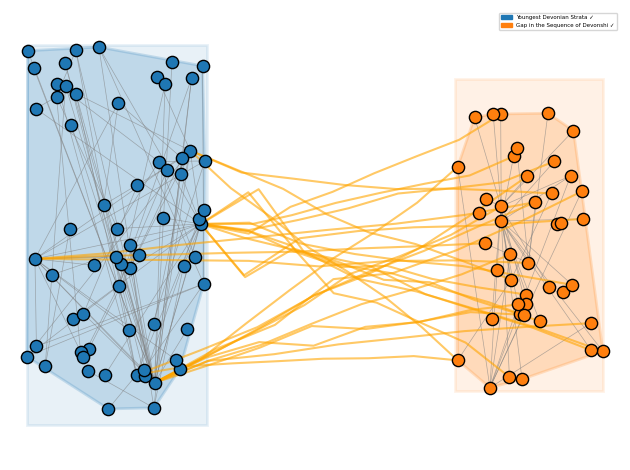

In [8]:
# Apply FDEB to inter-cluster edges
bundled_edges = apply_fdeb_to_inter_cluster_edges(G, pos, cluster1_nodes, cluster2_nodes, P=6, S=0.03, I=50, compatibility_threshold=0.06)

# drawing: 
actual_drawing_boundled(*visualization_elements, bundled_edges)

## Smoothing Process


In [ ]:
import numpy as np
import scipy.signal

def smooth_edge(x_coords, y_coords, kernel_width=11, sigma=2):

    # Generate Gaussian kernel
    kernel = gaussian(kernel_width, std=sigma)
    kernel /= kernel.sum()  # Normalize the kernel so weights add to one

    # Convolve x and y coordinates with the kernel
    smoothed_x = convolve(x_coords, kernel, mode='same')
    smoothed_y = convolve(y_coords, kernel, mode='same')

    # Fix boundary conditions: keep edge endpoints fixed
    smoothed_x[0], smoothed_x[-1] = x_coords[0], x_coords[-1]
    smoothed_y[0], smoothed_y[-1] = y_coords[0], y_coords[-1]

    return smoothed_x, smoothed_y

def resample_edge(x_coords, y_coords, num_points=100):

    # Compute cumulative distance along the edge
    distances = np.sqrt(np.diff(x_coords)**2 + np.diff(y_coords)**2)
    cumulative_distances = np.insert(np.cumsum(distances), 0, 0)

    # Generate equally spaced distances
    equally_spaced_distances = np.linspace(0, cumulative_distances[-1], num_points)

    # Interpolate x and y coordinates at equally spaced distances
    resampled_x = np.interp(equally_spaced_distances, cumulative_distances, x_coords)
    resampled_y = np.interp(equally_spaced_distances, cumulative_distances, y_coords)

    return resampled_x, resampled_y

def perform_additional_smoothing(edge_control_points, smooth_iterations=2, kernel_width=7, sigma=1.5):

    # We can reuse the smooth_bundled_edges function for additional smoothing
    further_smoothed_edges = smooth_bundled_edges(edge_control_points, iterations=smooth_iterations, kernel_width=kernel_width, sigma=sigma)
    
    # Optionally resample points to ensure equal spacing after additional smoothing
    resampled_smoothed_edges = resample_edge_points(further_smoothed_edges)
    
    return resampled_smoothed_edges

# Complete workflow function that includes initial bundling, smoothing, and additional smoothing
def complete_edge_bundling_workflow(G, pos, cluster1, cluster2, fdeb_params={'P': 6, 'S': 0.03, 'I': 50, 'compatibility_threshold': 0.06},
                                   initial_smoothing={'iterations': 2, 'kernel_width': 5, 'sigma': 1}, additional_smoothing={'iterations': 2, 'kernel_width': 7, 'sigma': 1.5}):

    #Extracting inter-cluster edges
    inter_cluster_edges = [(u, v) for u, v in G.edges() 
                          if (u in cluster1 and v in cluster2) or 
                             (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()
    
    # Applying force-directed edge bundling
    bundled_edges = force_directed_edge_bundling(subgraph, pos, **fdeb_params)
    
    # Applying initial smoothing
    initially_smoothed_edges = smooth_bundled_edges(bundled_edges, **initial_smoothing)
    initially_smoothed_edges = resample_edge_points(initially_smoothed_edges)
    
    # Applying additional smoothing
    further_smoothed_edges = perform_additional_smoothing(initially_smoothed_edges, **additional_smoothing)
    
    return further_smoothed_edges


def smooth_bundled_edges(edge_control_points, iterations=1, kernel_width=5, sigma=1):

    # Ensure kernel width is odd
    if kernel_width % 2 == 0:
        kernel_width += 1
    
    # Create and normalize Gaussian kernel
    kernel = scipy.signal.windows.gaussian(kernel_width, std=sigma)
    kernel = kernel / np.sum(kernel)  # Normalize to ensure weights sum to 1
    
    smoothed_control_points = {}
    
    for edge, points in edge_control_points.items():
        # Convert list of points to separate arrays of x and y coordinates
        x_coords = np.array([p[0] for p in points])
        y_coords = np.array([p[1] for p in points])
        
        # Save the original endpoints
        start_point = x_coords[0], y_coords[0]
        end_point = x_coords[-1], y_coords[-1]
        
        # Apply smoothing for the specified number of iterations
        for _ in range(iterations):
            # Smooth x and y coordinates separately
            x_smoothed = smooth_coordinates(x_coords, kernel)
            y_smoothed = smooth_coordinates(y_coords, kernel)
            
            # Update coordinates
            x_coords = x_smoothed
            y_coords = y_smoothed
            
            # Restore the original endpoints (they should remain fixed)
            x_coords[0], y_coords[0] = start_point
            x_coords[-1], y_coords[-1] = end_point
        
        # Convert back to list of points
        smoothed_points = [np.array([x, y]) for x, y in zip(x_coords, y_coords)]
        smoothed_control_points[edge] = smoothed_points
    
    return smoothed_control_points

def smooth_coordinates(coords, kernel):

    n = len(coords)
    k = len(kernel) // 2  # Half-width of kernel
    smoothed = np.zeros_like(coords)
    
    for i in range(n):
        # Determine valid indices for kernel application
        start_idx = max(0, i - k)
        end_idx = min(n, i + k + 1)
        kernel_start = k - (i - start_idx)
        kernel_end = k + (end_idx - i)
        
        # Extract valid portion of kernel
        valid_kernel = kernel[kernel_start:kernel_end]
        
        # Normalize the valid portion of kernel to ensure weights sum to 1
        valid_kernel = valid_kernel / np.sum(valid_kernel)
        
        # Compute weighted average using valid portions
        smoothed[i] = np.sum(valid_kernel * coords[start_idx:end_idx])
    
    return smoothed

def resample_edge_points(edge_control_points, num_points=None):

    resampled_points = {}
    
    for edge, points in edge_control_points.items():
        if num_points is None:
            num_points = len(points)
        
        # Calculate the total length of the path
        total_length = 0
        segments = []
        
        for i in range(len(points) - 1):
            segment_length = np.linalg.norm(points[i+1] - points[i])
            total_length += segment_length
            segments.append((points[i], points[i+1], segment_length))
        
        # Resample points at equal distances
        resampled = [points[0]]  # Start with the original first point
        
        for i in range(1, num_points - 1):
            target_length = total_length * i / (num_points - 1)
            
            # Find the segment containing this point
            current_length = 0
            for start, end, length in segments:
                if current_length + length >= target_length:
                    # Interpolate within this segment
                    ratio = (target_length - current_length) / length
                    new_point = start + ratio * (end - start)
                    resampled.append(new_point)
                    break
                current_length += length
        
        resampled.append(points[-1])  # End with the original last point
        resampled_points[edge] = resampled
    
    return resampled_points

# Augment the apply_fdeb_to_inter_cluster_edges function to include smoothing
def apply_fdeb_with_smoothing(G, pos, cluster1, cluster2, smooth_iterations=2, kernel_width=5, sigma=1, **kwargs):

    # First apply FDEB
    bundled_edges = apply_fdeb_to_inter_cluster_edges(G, pos, cluster1, cluster2, **kwargs)
    
    # Then smooth the results
    smoothed_edges = smooth_bundled_edges(bundled_edges, iterations=smooth_iterations, 
                                          kernel_width=kernel_width, sigma=sigma)
    
    # Resample the points to ensure equal spacing
    resampled_edges = resample_edge_points(smoothed_edges)
    
    return resampled_edges


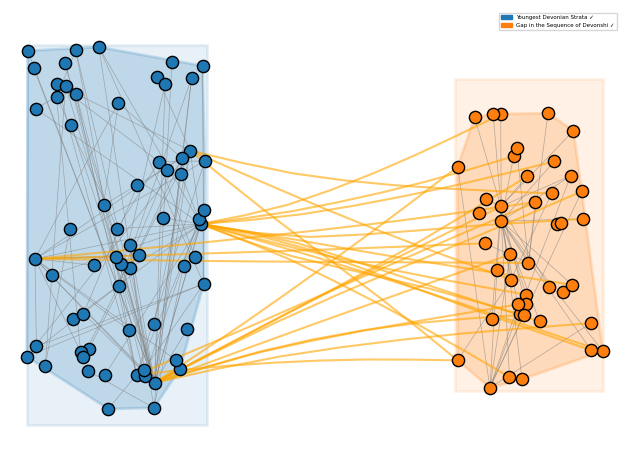

In [18]:
smoothed_bundled_edges = bundled_edges
# Apply additional smoothing to the already smoothed bundled edges
further_smoothed_edges = perform_additional_smoothing(smoothed_bundled_edges, smooth_iterations=2, kernel_width=7, sigma=1.5)

# drawing: 
actual_drawing_boundled(*visualization_elements, further_smoothed_edges)

## Multiple Edge Smoothing

In [58]:
def multi_pass_edge_smoothing(edge_control_points, num_passes, iterations_per_pass=1, kernel_width_schedule=None, sigma_schedule=None):
    
    if kernel_width_schedule is None:
        kernel_width_schedule = [3 + 2 * i for i in range(num_passes)] # Starting with a smaller kernel and gradually increase
    
    if sigma_schedule is None:
        sigma_schedule = [0.8 + 0.2 * i for i in range(num_passes)] # Starting with a smaller sigma and gradually increase
    
    # Convert iterations_per_pass to a list if it's a single value
    if isinstance(iterations_per_pass, int):
        iterations_per_pass = [iterations_per_pass] * num_passes
    
    # Validate parameters
    assert len(kernel_width_schedule) == num_passes, "kernel_width_schedule must have length equal to num_passes"
    assert len(sigma_schedule) == num_passes, "sigma_schedule must have length equal to num_passes"
    assert len(iterations_per_pass) == num_passes, "iterations_per_pass must have length equal to num_passes"
    

    current_edges = {e: points.copy() for e, points in edge_control_points.items()}
    
    # Store the intermediate results for visualization
    intermediate_results = [(current_edges.copy(), f"Original")]
    
    # Applying multiple passes of smoothing
    for i in range(num_passes):
        print(f"Applying smoothing pass {i+1}/{num_passes} with kernel_width={kernel_width_schedule[i]}, "
              f"sigma={sigma_schedule[i]}, iterations={iterations_per_pass[i]}")
        
        # Apply smoothing for this pass
        current_edges = smooth_bundled_edges(current_edges, iterations=iterations_per_pass[i], kernel_width=kernel_width_schedule[i], sigma=sigma_schedule[i]
        )
        
        # Resample points after each pass to maintain equal spacing
        current_edges = resample_edge_points(current_edges)
        #rint(f"current_edges: {current_edges}")
        actual_drawing_boundled(*visualization_elements, current_edges)
        # Store intermediate result
        #actual_drawing_boundled(*visualization_elements, intermediate_results)
        intermediate_results.append((current_edges.copy(), f"Pass {i+1}"))
        #print(f"intermediate_results: {intermediate_results}")
    
    return current_edges, intermediate_results


In [59]:
def visualize_smoothing_passes(G, pos, intermediate_results, figsize=(15, 10), ncols=3):

    print(intermediate_results)
    
    n_passes = len(intermediate_results)
    nrows = math.ceil(n_passes / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, (edges, pass_name) in enumerate(intermediate_results):
        if i < len(axes):
            ax = axes[i]
            ax.set_title(f"{pass_name}")
            
            # Draw nodes
            for node in G.nodes():
                ax.scatter(pos[node][0], pos[node][1], s=30, color='blue', edgecolor='black', zorder=2)
            
            # Draw edges
            for e, points in edges.items():
                points_array = np.array(points)
                ax.plot(points_array[:, 0], points_array[:, 1], color='gray', alpha=0.6, zorder=1)
            
            ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_passes, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    return fig


def apply_multi_pass_smoothing(G, pos, cluster1, cluster2, num_passes=3, fdeb_params=None, ierations_per_pass=None, kernel_width_schedule=None, sigma_schedule=None):
   
    # Extracting the inter-cluster edges
    inter_cluster_edges = [(u, v) for u, v in G.edges() if (u in cluster1 and v in cluster2) or (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()
    
    # Apply force-directed edge bundling
    bundled_edges = force_directed_edge_bundling(subgraph, pos, **fdeb_params)
    
    # Apply multi-pass smoothing
    final_edges, intermediate_results = multi_pass_edge_smoothing(
        bundled_edges, 
        num_passes, 
        iterations_per_pass=iterations_per_pass,
        kernel_width_schedule=kernel_width_schedule, 
        sigma_schedule=sigma_schedule
    )
    
    print(f"\n\nFinal Edges: {final_edges}")
    print(f"\nIntermediate Results: {intermediate_results}")
    return final_edges, intermediate_results

In [60]:
def edge_smoothing_with_iterations(G, pos, cluster1, cluster2, iterations, fdeb_params=None):
    # Default FDEB parameters
    if fdeb_params is None:
        fdeb_params = {'P': 6, 'S': 0.03, 'I': 50, 'compatibility_threshold': 0.06}

    # Extract inter-cluster edges
    inter_cluster_edges = [(u, v) for u, v in G.edges() 
                          if (u in cluster1 and v in cluster2) or 
                             (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()

    # Apply force-directed edge bundling
    bundled_edges = force_directed_edge_bundling(subgraph, pos, **fdeb_params)

    # Set the number of passes equal to the number of iterations
    num_passes = iterations

    # Use 1 iteration per pass (since the number of passes equals the total iterations)
    iterations_per_pass = [1] * num_passes

    # Defining the kernel width and sigma
    kernel_width_schedule = [3 + 2 * i for i in range(num_passes)]  
    sigma_schedule = [0.8 + 0.2 * i for i in range(num_passes)]  
    # Apply multi-pass smoothing
    final_edges, intermediate_results = multi_pass_edge_smoothing( bundled_edges, num_passes, iterations_per_pass=iterations_per_pass, kernel_width_schedule=kernel_width_schedule, 
        sigma_schedule=sigma_schedule)

    # Visualize the results
    fig = visualize_smoothing_passes(G, pos, intermediate_results)
    #actual_drawing_boundled(*visualization_elements, further_smoothed_edges)
    #actual_drawing_boundled(*visualization_elements, bundled_edges)
    plt.show()

    return final_edges

Applying smoothing pass 1/5 with kernel_width=3, sigma=0.8, iterations=1


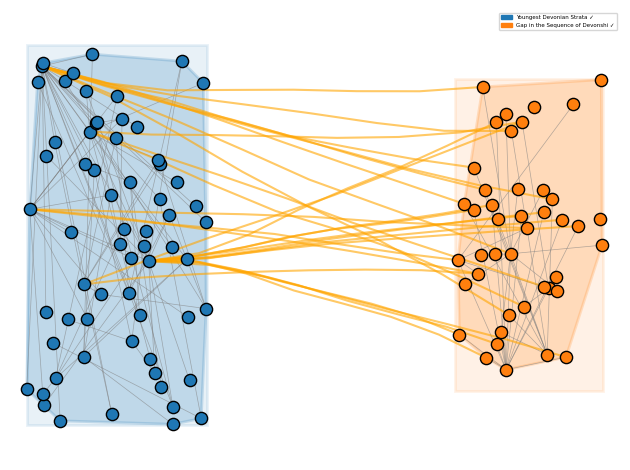

Applying smoothing pass 2/5 with kernel_width=5, sigma=1.0, iterations=1


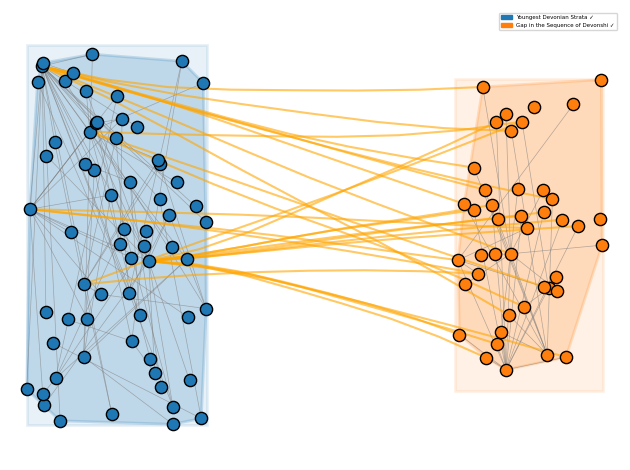

Applying smoothing pass 3/5 with kernel_width=7, sigma=1.2000000000000002, iterations=1


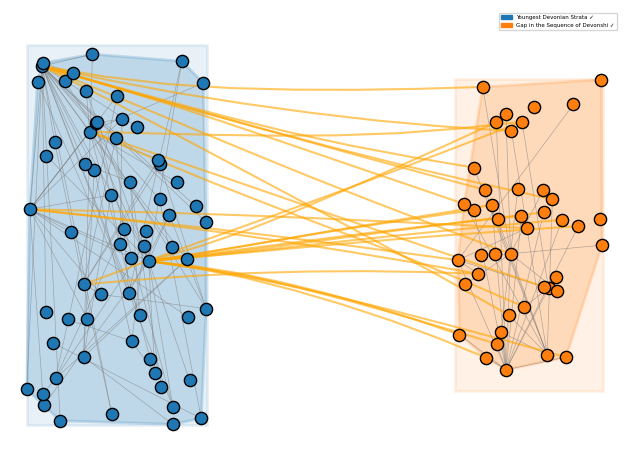

Applying smoothing pass 4/5 with kernel_width=9, sigma=1.4000000000000001, iterations=1


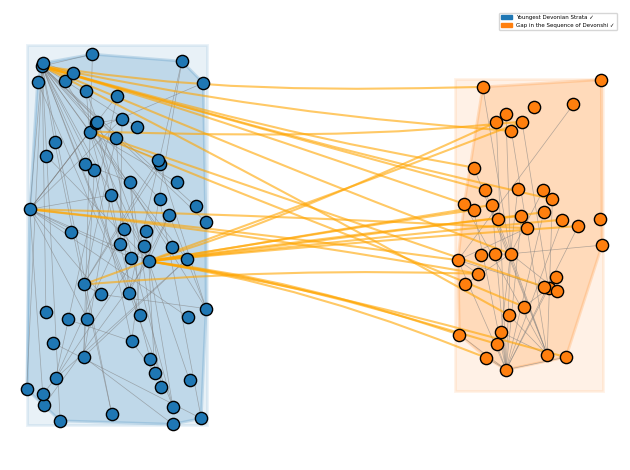

Applying smoothing pass 5/5 with kernel_width=11, sigma=1.6, iterations=1


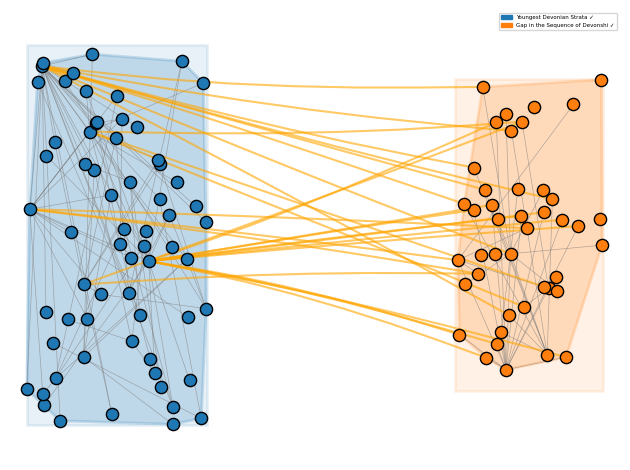

[({('n149', 'n331'): [array([0.10160332, 3.2114291 ]), array([2.34617957, 3.18487939]), array([4.60254942, 3.16142482]), array([6.83313666, 3.12714837]), array([9.00347664, 3.13471072]), array([11.12521078,  2.98568131]), array([13.41559964,  2.9954574 ]), array([15.65398408,  2.92973508])], ('n149', 'n332'): [array([0.10160332, 3.2114291 ]), array([2.20720713, 3.14675633]), array([4.23719573, 2.99790381]), array([6.25293222, 2.86229072]), array([8.25510099, 2.74874705]), array([10.25173617,  2.57726344]), array([12.22194659,  2.42275167]), array([14.12277754,  2.25366888])], ('n137', 'n304'): [array([3.82218363, 2.44099696]), array([5.43509245, 2.48764288]), array([6.85978516, 2.24720709]), array([8.39973641, 2.15939225]), array([9.90044978, 1.82438942]), array([11.49794035,  1.66426252]), array([13.10782045,  1.50073849]), array([14.70699106,  1.20950174])], ('n137', 'n305'): [array([3.82218363, 2.44099696]), array([5.39507634, 2.41611814]), array([7.11352066, 2.59560902]), array([9.

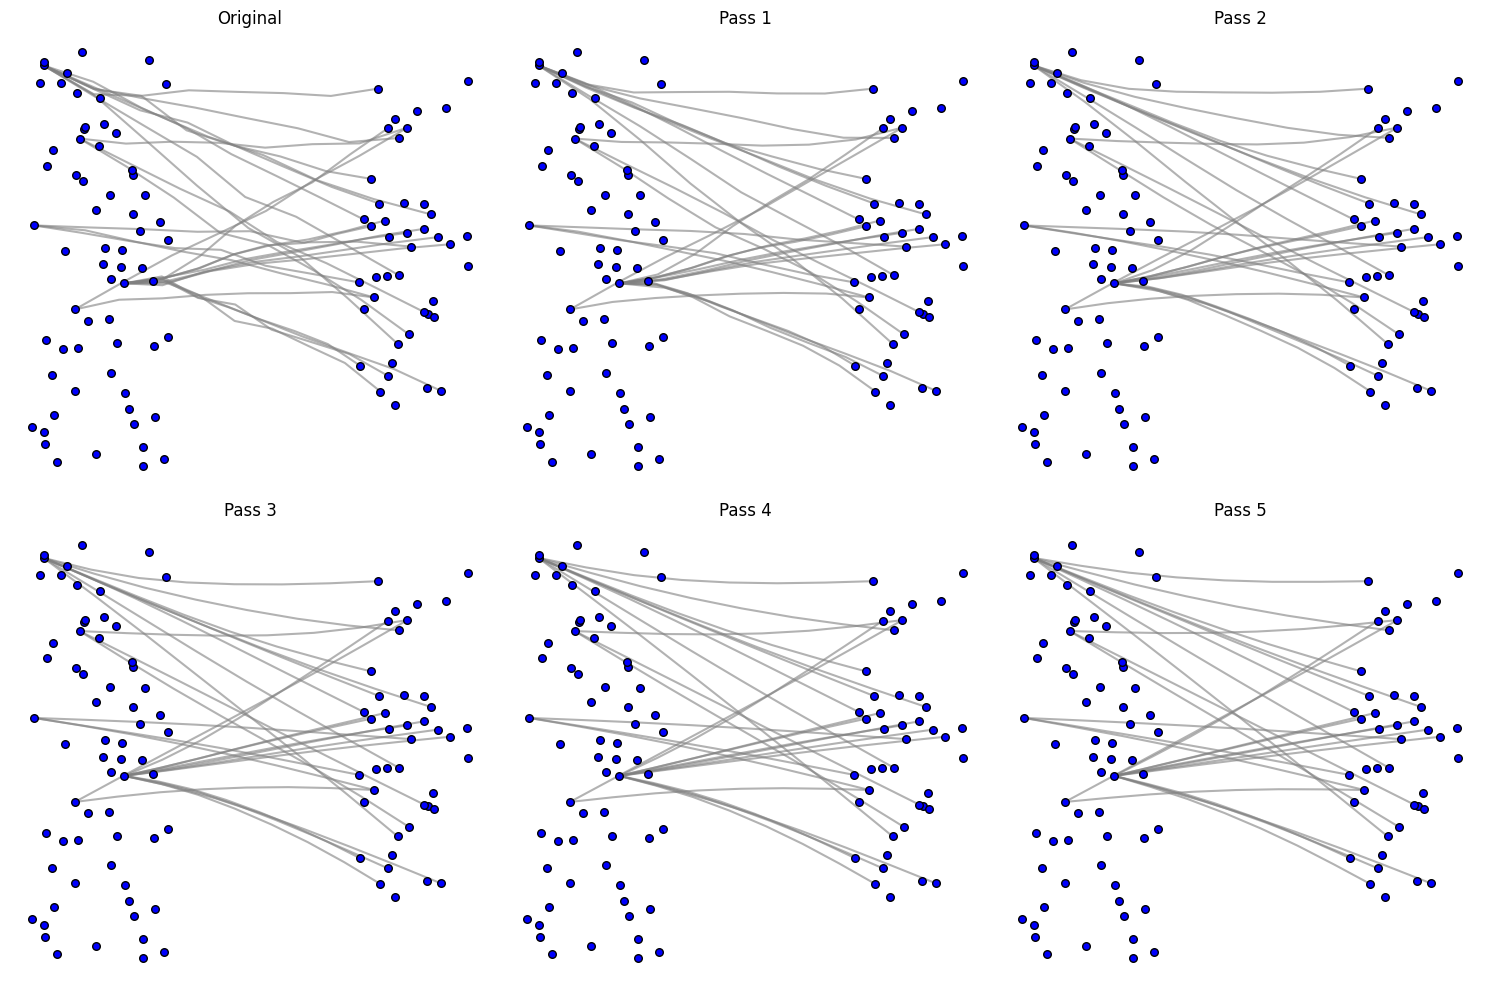

In [ ]:
# Define the number of iterations
num_iterations = 5  # User-defined number of times the smoothing takes place

# FDEB parameters for the smoothings passes
fdeb_params = {'P': 6, 'S': 0.03, 'I': 50, 'compatibility_threshold': 0.06}


# Edge smoothing with iterations
final_smoothed_edges = edge_smoothing_with_iterations(G, pos, cluster1_nodes, cluster2_nodes, iterations=num_iterations, fdeb_params=fdeb_params)